In [2]:
"""
Adds a new repeatable Program Stage "Raw Sensor Reading" to the existing
Diabetes Registry program, with two data elements:
  - Reading Type (text: HR, SPO2, STRESS, RESP, GLUCOSE, SLEEP, ACTIVITY, CALORIE)
  - Reading Value (number)

This keeps metadata simple regardless of how many raw metrics we import -
each individual reading becomes one event with a type + value, dated to
the actual reading timestamp.

USAGE:
  1. Fill in DHIS2_URL, ADMIN_USER, ADMIN_PASS, PROGRAM_UID below
     (verify PROGRAM_UID via API first, per your handoff doc's warning
     about UIDs shifting after resets)
  2. Run: python3 add_raw_reading_metadata.py
  3. It prints the new Program Stage UID and two Data Element UIDs -
     SAVE THESE into your uid_lookup.json under a new key, e.g.:
       "raw_sensor_reading_stage": "<stage_uid>",
       "reading_type_de": "<de_uid>",
       "reading_value_de": "<de_uid>"
"""

import requests
import json

DHIS2_URL = "https://t2d-registry.plhi.us"
ADMIN_USER = "admin"
ADMIN_PASS = "Londonbridge@2026"  # never leave this hardcoded/committed - fill in locally, don't paste back into chat

# Verify this first: curl -u admin:PASS "https://t2d-registry.plhi.us/api/programs?filter=name:eq:Diabetes%20Registry&fields=id,name"
PROGRAM_UID = "REPLACE_ME"

auth = (ADMIN_USER, ADMIN_PASS)
headers = {"Content-Type": "application/json"}

# --- Step 1: create the two Data Elements ---
data_elements_payload = {
    "dataElements": [
        {
            "name": "Raw Reading Type",
            "shortName": "Reading Type",
            "domainType": "TRACKER",
            "valueType": "TEXT",
            "aggregationType": "NONE",
            "optionSet": None,  # could add an option set with HR/SPO2/STRESS/etc if you want dropdown validation
        },
        {
            "name": "Raw Reading Value",
            "shortName": "Reading Value",
            "domainType": "TRACKER",
            "valueType": "NUMBER",
            "aggregationType": "AVERAGE",
        },
    ]
}

resp = requests.post(
    f"{DHIS2_URL}/api/metadata",
    auth=auth,
    headers=headers,
    data=json.dumps(data_elements_payload),
)
print("Data element creation response:", resp.status_code)
print(resp.text)

if resp.status_code not in (200, 201):
    print("STOPPING - fix the above error before continuing")
    exit(1)

# Pull back the created UIDs by name (since we didn't specify UIDs)
de_lookup = requests.get(
    f"{DHIS2_URL}/api/dataElements",
    auth=auth,
    params={
        "filter": "name:in:[Raw Reading Type,Raw Reading Value]",
        "fields": "id,name",
    },
).json()

reading_type_de = None
reading_value_de = None
for de in de_lookup.get("dataElements", []):
    if de["name"] == "Raw Reading Type":
        reading_type_de = de["id"]
    elif de["name"] == "Raw Reading Value":
        reading_value_de = de["id"]

print(f"\nReading Type DE UID: {reading_type_de}")
print(f"Reading Value DE UID: {reading_value_de}")

if not (reading_type_de and reading_value_de):
    print("Could not find both data elements - check DHIS2 Maintenance app manually")
    exit(1)

# --- Step 2: create the Program Stage, attached to the existing program ---
program_stage_payload = {
    "programStages": [
        {
            "name": "Raw Sensor Reading",
            "program": {"id": PROGRAM_UID},
            "repeatable": True,
            "featureType": "NONE",
            "programStageDataElements": [
                {
                    "dataElement": {"id": reading_type_de},
                    "compulsory": True,
                    "sortOrder": 1,
                },
                {
                    "dataElement": {"id": reading_value_de},
                    "compulsory": True,
                    "sortOrder": 2,
                },
            ],
        }
    ]
}

resp2 = requests.post(
    f"{DHIS2_URL}/api/metadata",
    auth=auth,
    headers=headers,
    data=json.dumps(program_stage_payload),
)
print("\nProgram stage creation response:", resp2.status_code)
print(resp2.text)

stage_lookup = requests.get(
    f"{DHIS2_URL}/api/programStages",
    auth=auth,
    params={"filter": "name:eq:Raw Sensor Reading", "fields": "id,name"},
).json()

for stage in stage_lookup.get("programStages", []):
    print(f"\nRaw Sensor Reading Program Stage UID: {stage['id']}")

print("\n=== SAVE THESE INTO uid_lookup.json ===")
print(json.dumps({
    "raw_sensor_reading_stage": stage_lookup["programStages"][0]["id"] if stage_lookup.get("programStages") else None,
    "reading_type_de": reading_type_de,
    "reading_value_de": reading_value_de,
}, indent=2))

Data element creation response: 200
{"httpStatus":"OK","httpStatusCode":200,"status":"OK","response":{"status":"OK","typeReports":[{"klass":"org.hisp.dhis.dataelement.DataElement","stats":{"created":2,"updated":0,"deleted":0,"ignored":0,"total":2},"objectReports":[]}],"stats":{"created":2,"updated":0,"deleted":0,"ignored":0,"total":2},"responseType":"ImportReport"}}

Reading Type DE UID: LaiwCkD4n6T
Reading Value DE UID: si4gvm8gstH

Program stage creation response: 409
{"httpStatus":"Conflict","httpStatusCode":409,"status":"WARNING","message":"One or more errors occurred, please see full details in import report.","response":{"status":"ERROR","typeReports":[{"klass":"org.hisp.dhis.program.ProgramStage","stats":{"created":0,"updated":0,"deleted":0,"ignored":2,"total":2},"objectReports":[{"klass":"org.hisp.dhis.program.ProgramStage","index":0,"uid":"kYBelojR9zP","errorReports":[{"message":"Invalid reference [REPLACE_ME] (Program) on object Raw Sensor Reading [kYBelojR9zP] (ProgramStage)

In [5]:
!curl -u admin:Londonbridge@2026 "https://t2d-registry.plhi.us/api/programs?filter=name:eq:Diabetes%20Registry&fields=id,name"

{"pager":{"page":1,"pageSize":50,"total":1,"pageCount":1},"gist":true,"programs":[{"id":"W3LSFZH3UDq","name":"Diabetes Registry"}]}

In [6]:
import requests
import json

DHIS2_URL = 'https://t2d-registry.plhi.us'
ADMIN_USER = 'admin'
ADMIN_PASS = 'Londonbridge@2026'  # fill in locally, don't share it in chat

PROGRAM_UID = 'W3LSFZH3UDq'
READING_TYPE_DE = 'LaiwCkD4n6T'
READING_VALUE_DE = 'si4gvm8gstH'

payload = {
    'programStages': [{
        'name': 'Raw Sensor Reading',
        'program': {'id': PROGRAM_UID},
        'repeatable': True,
        'featureType': 'NONE',
        'programStageDataElements': [
            {'dataElement': {'id': READING_TYPE_DE}, 'compulsory': True, 'sortOrder': 1},
            {'dataElement': {'id': READING_VALUE_DE}, 'compulsory': True, 'sortOrder': 2},
        ],
    }]
}

resp = requests.post(
    f'{DHIS2_URL}/api/metadata',
    auth=(ADMIN_USER, ADMIN_PASS),
    headers={'Content-Type': 'application/json'},
    data=json.dumps(payload)
)
print(resp.status_code)
print(resp.text)

200
{"httpStatus":"OK","httpStatusCode":200,"status":"OK","response":{"status":"OK","typeReports":[{"klass":"org.hisp.dhis.program.ProgramStage","stats":{"created":1,"updated":0,"deleted":0,"ignored":0,"total":1},"objectReports":[]}],"stats":{"created":1,"updated":0,"deleted":0,"ignored":0,"total":1},"responseType":"ImportReport"}}


In [7]:
stage_lookup = requests.get(
    f'{DHIS2_URL}/api/programStages',
    auth=(ADMIN_USER, ADMIN_PASS),
    params={'filter': 'name:eq:Raw Sensor Reading', 'fields': 'id,name'}
).json()

print(stage_lookup)

{'pager': {'page': 1, 'pageSize': 50, 'total': 1, 'pageCount': 1}, 'gist': True, 'programStages': [{'id': 'UPhyn3GuXDS', 'name': 'Raw Sensor Reading'}]}


In [8]:
import subprocess
result = subprocess.run(['cat', '/tmp/pilot_ids.txt'], capture_output=True, text=True)
print(result.stdout if result.stdout else "File doesn't exist or is empty")

File doesn't exist or is empty


In [9]:
!cd ~/AI-READI-fixed && comm -12 <(comm -12 <(cut -f1 wearable_activity_monitor/manifest.tsv | tail -n +2 | sort -u) <(cut -f1 wearable_blood_glucose/manifest.tsv | tail -n +2 | sort -u)) <(cut -f1 cardiac_ecg/manifest.tsv | tail -n +2 | sort -u) | head -15 > /tmp/pilot_ids.txt
!cat /tmp/pilot_ids.txt

comm: write error: Broken pipe
1023
1024
1026
1027
1029
1030
1031
1032
1033
1034
1035
1036
1037
1038
1039


In [10]:
import json
import csv
import time
import requests

DHIS2_URL = 'https://t2d-registry.plhi.us'
ADMIN_USER = 'admin'
ADMIN_PASS = 'Londonbridge@2026'  # fill in locally

PROGRAM_UID = 'W3LSFZH3UDq'
RAW_STAGE_UID = 'UPhyn3GuXDS'
READING_TYPE_DE = 'LaiwCkD4n6T'
READING_VALUE_DE = 'si4gvm8gstH'
PERSON_ID_ATTR_UID = 'oFbmOHnKYaX'

AI_READI_ROOT = '/home/jupyter-ainaperu/AI-READI-fixed'

PILOT_PERSON_IDS = ['1023', '1024', '1026', '1027', '1029', '1030',
                    '1031', '1032', '1033', '1034', '1035', '1036',
                    '1037', '1038', '1039']

BATCH_SIZE = 500

session = requests.Session()
session.auth = (ADMIN_USER, ADMIN_PASS)

print(f"Config loaded. Pilot set: {len(PILOT_PERSON_IDS)} participants")

Config loaded. Pilot set: 15 participants


In [11]:
def load_manifest(path):
    with open(path) as f:
        reader = csv.DictReader(f, delimiter='\t')
        return {row['person_id']: row for row in reader}

wam_manifest = load_manifest(f'{AI_READI_ROOT}/wearable_activity_monitor/manifest.tsv')
bg_manifest = load_manifest(f'{AI_READI_ROOT}/wearable_blood_glucose/manifest.tsv')

print(f"Wearable activity manifest: {len(wam_manifest)} participants")
print(f"Blood glucose manifest: {len(bg_manifest)} participants")

# Quick sanity check - confirm our pilot IDs are actually in both manifests
missing_wam = [pid for pid in PILOT_PERSON_IDS if pid not in wam_manifest]
missing_bg = [pid for pid in PILOT_PERSON_IDS if pid not in bg_manifest]
print(f"Pilot IDs missing from wearable manifest: {missing_wam}")
print(f"Pilot IDs missing from glucose manifest: {missing_bg}")


Wearable activity manifest: 2184 participants
Blood glucose manifest: 2245 participants
Pilot IDs missing from wearable manifest: []
Pilot IDs missing from glucose manifest: []


In [12]:
def get_ts(effective_time_frame):
    """Handle both point-in-time and interval timestamp formats."""
    if 'date_time' in effective_time_frame:
        return effective_time_frame['date_time']
    return effective_time_frame['time_interval']['start_date_time']


def extract_heart_rate(filepath):
    with open(filepath) as f:
        data = json.load(f)
    return [(get_ts(r['effective_time_frame']), r['heart_rate']['value'])
            for r in data['body']['heart_rate']]


def extract_oxygen_saturation(filepath):
    with open(filepath) as f:
        data = json.load(f)
    return [(get_ts(r['effective_time_frame']), r['oxygen_saturation']['value'])
            for r in data['body']['breathing'] if 'oxygen_saturation' in r]


def extract_respiratory_rate(filepath):
    with open(filepath) as f:
        data = json.load(f)
    out = []
    for r in data['body']['breathing']:
        if 'respiratory_rate' in r:
            val = r['respiratory_rate']['value']
            if val is not None and val >= 0:  # drop sentinel negatives
                out.append((get_ts(r['effective_time_frame']), val))
    return out


def extract_stress(filepath):
    with open(filepath) as f:
        data = json.load(f)
    out = []
    for r in data['body']['stress']:
        val = r['stress']['value']
        if val is not None and val >= 0:
            out.append((get_ts(r['effective_time_frame']), val))
    return out


def extract_calories(filepath):
    with open(filepath) as f:
        data = json.load(f)
    return [(get_ts(r['effective_time_frame']), r['calories_value']['value'])
            for r in data['body']['activity'] if r.get('activity_name') == 'kcal_burned']


def extract_activity_steps(filepath):
    with open(filepath) as f:
        data = json.load(f)
    out = []
    for r in data['body']['activity']:
        val = r['base_movement_quantity']['value']
        if val != '' and val is not None:
            out.append((get_ts(r['effective_time_frame']), val))
    return out


SLEEP_STAGE_CODES = {'awake': 0, 'light': 1, 'deep': 2, 'rem': 3}

def extract_sleep(filepath):
    with open(filepath) as f:
        data = json.load(f)
    out = []
    for r in data['body']['sleep']:
        code = SLEEP_STAGE_CODES.get(r['sleep_stage_state'])
        if code is not None:
            out.append((get_ts(r['effective_time_frame']), code))
    return out


def extract_glucose(filepath):
    with open(filepath) as f:
        data = json.load(f)
    return [(get_ts(r['effective_time_frame']), r['blood_glucose']['value'])
            for r in data['body']['cgm']]


METRIC_EXTRACTORS = {
    'HR': ('heartrate_filepath', extract_heart_rate),
    'SPO2': ('oxygen_saturation_filepath', extract_oxygen_saturation),
    'RESP': ('respiratory_rate_filepath', extract_respiratory_rate),
    'STRESS': ('stress_level_filepath', extract_stress),
    'CALORIE': ('active_calories_filepath', extract_calories),
    'ACTIVITY': ('physical_activity_filepath', extract_activity_steps),
    'SLEEP': ('sleep_filepath', extract_sleep),
}

print("Extraction functions loaded for:", list(METRIC_EXTRACTORS.keys()), "+ GLUCOSE (separate manifest)")

Extraction functions loaded for: ['HR', 'SPO2', 'RESP', 'STRESS', 'CALORIE', 'ACTIVITY', 'SLEEP'] + GLUCOSE (separate manifest)


In [13]:
test_person = '1023'
wam_row = wam_manifest[test_person]
bg_row = bg_manifest[test_person]

print(f"=== Testing extraction for person_id {test_person} ===\n")

for metric_code, (col_name, extractor) in METRIC_EXTRACTORS.items():
    filepath_suffix = wam_row.get(col_name)
    full_path = f"{AI_READI_ROOT}{filepath_suffix}" if filepath_suffix.startswith('/') else f"{AI_READI_ROOT}/{filepath_suffix}"
    try:
        readings = extractor(full_path)
        print(f"{metric_code}: {len(readings)} readings extracted")
        if readings:
            print(f"  sample: {readings[0]}")
    except Exception as e:
        print(f"{metric_code}: ERROR - {e}")
    print()

# Glucose separately
glucose_path_suffix = bg_row.get('glucose_filepath')
full_path = f"{AI_READI_ROOT}{glucose_path_suffix}" if glucose_path_suffix.startswith('/') else f"{AI_READI_ROOT}/{glucose_path_suffix}"
try:
    readings = extract_glucose(full_path)
    print(f"GLUCOSE: {len(readings)} readings extracted")
    if readings:
        print(f"  sample: {readings[0]}")
except Exception as e:
    print(f"GLUCOSE: ERROR - {e}")

=== Testing extraction for person_id 1023 ===

HR: 12780 readings extracted
  sample: ('2023-08-30T16:11:57Z', 0)

SPO2: 2194 readings extracted
  sample: ('2023-08-31T07:10:57Z', 93)

RESP: 13016 readings extracted
  sample: ('2023-08-30T16:16:57Z', 16.99)

STRESS: 10874 readings extracted
  sample: ('2023-08-30T16:16:57Z', 58)

CALORIE: 1573 readings extracted
  sample: ('2023-08-30T18:06:57Z', 3)

ACTIVITY: 5522 readings extracted
  sample: ('2023-08-30T16:09:57Z', 0)

SLEEP: 328 readings extracted
  sample: ('2023-08-31T04:33:57Z', 1)

GLUCOSE: 2816 readings extracted
  sample: ('2023-08-30T17:53:21Z', 133)


In [14]:
def inspect_raw_values(filepath, body_key, value_key):
    with open(filepath) as f:
        data = json.load(f)
    values = [r[value_key]['value'] for r in data['body'][body_key] if value_key in r]
    negative_count = sum(1 for v in values if v is not None and v < 0)
    from collections import Counter
    neg_value_counts = Counter(v for v in values if v is not None and v < 0)
    print(f"Total: {len(values)}, Negative: {negative_count} ({100*negative_count/len(values):.1f}%)")
    print(f"Distinct negative values seen: {dict(neg_value_counts)}")

print("=== Respiratory rate ===")
resp_path = f"{AI_READI_ROOT}{wam_row['respiratory_rate_filepath']}"
inspect_raw_values(resp_path, 'breathing', 'respiratory_rate')

print("\n=== Stress ===")
stress_path = f"{AI_READI_ROOT}{wam_row['stress_level_filepath']}"
inspect_raw_values(stress_path, 'stress', 'stress')

=== Respiratory rate ===
Total: 24642, Negative: 11626 (47.2%)
Distinct negative values seen: {-1.0: 3929, -2.0: 7697}

=== Stress ===
Total: 24659, Negative: 13785 (55.9%)
Distinct negative values seen: {-2: 2908, -1: 10877}


In [15]:
def get_tei_info(person_id):
    resp = session.get(
        f'{DHIS2_URL}/api/tracker/trackedEntities',
        params={
            'program': PROGRAM_UID,
            'filter': f'{PERSON_ID_ATTR_UID}:eq:{person_id}',
            'fields': 'trackedEntity,orgUnit,enrollments[enrollment]',
        },
    )
    resp.raise_for_status()
    data = resp.json()
    instances = data.get('instances', [])
    if not instances:
        print(f"  WARNING: no existing TEI found for person_id {person_id}")
        return None
    tei = instances[0]
    enrollment = tei['enrollments'][0]['enrollment'] if tei.get('enrollments') else None
    return {'trackedEntity': tei['trackedEntity'], 'orgUnit': tei['orgUnit'], 'enrollment': enrollment}

# Test on one participant first
test_tei = get_tei_info('1023')
print(test_tei)

None


In [16]:
# Step 1: Just query without any filter to see if this endpoint works at all
resp = session.get(
    f'{DHIS2_URL}/api/tracker/trackedEntities',
    params={
        'program': PROGRAM_UID,
        'pageSize': 3,
        'fields': 'trackedEntity,orgUnit,attributes',
    },
)
print(resp.status_code)
print(resp.text[:2000])

200
{"pager":{"page":1,"pageSize":3,"nextPage":"https://t2d-registry.plhi.us/api/tracker/trackedEntities?program=W3LSFZH3UDq&pageSize=3&fields=trackedEntity%2CorgUnit%2Cattributes&page=2"},"trackedEntities":[{"trackedEntity":"UmM6CBbnviQ","orgUnit":"jZmnwTrmXnR","attributes":[{"attribute":"oFbmOHnKYaX","displayName":"AI-READI Person ID","createdAt":"2026-07-25T16:33:04.399","updatedAt":"2026-07-25T16:33:04.399","updatedBy":"admin","valueType":"TEXT","value":"7767"},{"attribute":"SArnVgxwvqc","displayName":"Year of Birth","createdAt":"2026-07-25T16:33:04.399","updatedAt":"2026-07-25T16:33:04.399","updatedBy":"admin","valueType":"NUMBER","value":"1970"},{"attribute":"DH8xIZM1JRc","displayName":"Marital Status","createdAt":"2026-07-25T16:33:04.399","updatedAt":"2026-07-25T16:33:04.399","updatedBy":"admin","valueType":"TEXT","value":"C51776"},{"attribute":"oV911xCZkwP","displayName":"Diabetes Severity Group","createdAt":"2026-07-25T16:33:04.399","updatedAt":"2026-07-25T16:33:04.399","updat

In [17]:
# Test the filter using the real value "7767" we just saw, to isolate whether "filter" syntax itself works
resp = session.get(
    f'{DHIS2_URL}/api/tracker/trackedEntities',
    params={
        'program': PROGRAM_UID,
        'filter': 'oFbmOHnKYaX:eq:7767',
        'fields': 'trackedEntity,orgUnit,attributes',
    },
)
print(resp.status_code)
print(resp.text[:1000])

200
{"pager":{"page":1,"pageSize":50},"trackedEntities":[{"trackedEntity":"UmM6CBbnviQ","orgUnit":"jZmnwTrmXnR","attributes":[{"attribute":"PvsjaSS8VFg","displayName":"Recommended ML Train/Val/Test Split","createdAt":"2026-07-25T16:33:04.399","updatedAt":"2026-07-25T16:33:04.399","updatedBy":"admin","valueType":"TEXT","value":"train"},{"attribute":"S6OLkTkx9NI","displayName":"Type 2 Diabetes Status (self-reported)","createdAt":"2026-07-25T16:33:04.399","updatedAt":"2026-07-25T16:33:04.399","updatedBy":"admin","valueType":"BOOLEAN","value":"true"},{"attribute":"oFbmOHnKYaX","displayName":"AI-READI Person ID","createdAt":"2026-07-25T16:33:04.399","updatedAt":"2026-07-25T16:33:04.399","updatedBy":"admin","valueType":"TEXT","value":"7767"},{"attribute":"yx9G81aSQHq","displayName":"Clinical Recruitment Site","createdAt":"2026-07-25T16:33:04.399","updatedAt":"2026-07-25T16:33:04.399","updatedBy":"admin","valueType":"TEXT","value":"UAB"},{"attribute":"DH8xIZM1JRc","displayName":"Marital Statu

In [18]:
# Check the actual header of registry_master_v3.csv to find which column is really person_id
result = subprocess.run(['head', '-1', '/home/jupyter-ainaperu/diabetes_registry_project/registry_master_v3.csv'],
                         capture_output=True, text=True)
print(result.stdout)

person_id,year_of_birth,cage,cl_maristat,dmlact,fh_dm2pt,fh_dm2sb,mhoccur_circ,mhoccur_clsh,mhoccur_hbp,mhoccur_mi,mhoccur_obs,mhoccur_pdr,mhoccur_strk,mhterm_dm2,mhterm_predm,pxfi1,pxfi2,pxfi3,pxfi4,pxfi5,sualckncf,susmkcdur,susmkncf,bmi_vsorres,bp1_diabp_vsorres,bp1_sysbp_vsorres,height_vsorres,hip_vsorres,pulse_vsorres,waist_vsorres,weight_vsorres,whr_vsorres,average_glucose_level_mg_dl,glucose_level_record_count,glucose_sensor_sampling_duration_days,study_group,clinical_site,recommended_split



In [19]:
result = subprocess.run(
    ['bash', '-c', "cut -d',' -f1 /home/jupyter-ainaperu/diabetes_registry_project/registry_master_v3.csv | tail -n +2 | sort -u | head -20"],
    capture_output=True, text=True
)
print(result.stdout)
print("STDERR:", result.stderr)

1001
1002
1003
1004
1005
1006
1007
1008
1009
1010
1011
1012
1013
1014
1015
1016
1017
1018
1019
1020

STDERR: 


In [20]:
resp = session.get(
    f'{DHIS2_URL}/api/tracker/trackedEntities',
    params={
        'program': PROGRAM_UID,
        'filter': 'oFbmOHnKYaX:eq:1001',
        'fields': 'trackedEntity,orgUnit,attributes',
    },
)
print(resp.status_code)
print(resp.text[:1500])

200
{"pager":{"page":1,"pageSize":50},"trackedEntities":[{"trackedEntity":"Fhsocq73yfM","orgUnit":"dFnKYalCXGc","attributes":[{"attribute":"PvsjaSS8VFg","displayName":"Recommended ML Train/Val/Test Split","createdAt":"2026-07-25T16:33:02.687","updatedAt":"2026-07-25T16:33:02.687","updatedBy":"admin","valueType":"TEXT","value":"train"},{"attribute":"S6OLkTkx9NI","displayName":"Type 2 Diabetes Status (self-reported)","createdAt":"2026-07-25T16:33:02.687","updatedAt":"2026-07-25T16:33:02.687","updatedBy":"admin","valueType":"BOOLEAN","value":"false"},{"attribute":"RuVdYXye4JS","displayName":"Pre-Diabetes Status","createdAt":"2026-07-25T16:33:02.687","updatedAt":"2026-07-25T16:33:02.687","updatedBy":"admin","valueType":"BOOLEAN","value":"false"},{"attribute":"oFbmOHnKYaX","displayName":"AI-READI Person ID","createdAt":"2026-07-25T16:33:02.687","updatedAt":"2026-07-25T16:33:02.687","updatedBy":"admin","valueType":"TEXT","value":"1001"},{"attribute":"yx9G81aSQHq","displayName":"Clinical Recr

In [21]:
resp2 = session.get(
    f'{DHIS2_URL}/api/tracker/trackedEntities',
    params={
        'program': PROGRAM_UID,
        'pageSize': 10,
        'fields': 'attributes[attribute,value]',
    },
)
data = resp2.json()
for te in data.get('trackedEntities', []):
    for attr in te.get('attributes', []):
        if attr['attribute'] == 'oFbmOHnKYaX':
            print(attr['value'])

7767
7488
7793
7746
7812
7534
7798
7758
7479
7552


In [22]:
resp = session.get(
    f'{DHIS2_URL}/api/tracker/trackedEntities',
    params={
        'program': PROGRAM_UID,
        'filter': 'oFbmOHnKYaX:eq:1023',
        'fields': 'trackedEntity,orgUnit,attributes',
    },
)
print(resp.status_code)
print(resp.text[:800])

200
{"pager":{"page":1,"pageSize":50},"trackedEntities":[{"trackedEntity":"Kfi7YyUVT9K","orgUnit":"dFnKYalCXGc","attributes":[{"attribute":"PvsjaSS8VFg","displayName":"Recommended ML Train/Val/Test Split","createdAt":"2026-07-25T16:33:04.109","updatedAt":"2026-07-25T16:33:04.109","updatedBy":"admin","valueType":"TEXT","value":"train"},{"attribute":"S6OLkTkx9NI","displayName":"Type 2 Diabetes Status (self-reported)","createdAt":"2026-07-25T16:33:04.109","updatedAt":"2026-07-25T16:33:04.109","updatedBy":"admin","valueType":"BOOLEAN","value":"true"},{"attribute":"oFbmOHnKYaX","displayName":"AI-READI Person ID","createdAt":"2026-07-25T16:33:04.109","updatedAt":"2026-07-25T16:33:04.109","updatedBy":"admin","valueType":"TEXT","value":"1023"},{"attribute":"yx9G81aSQHq","displayName":"Clinical Recruit


In [23]:
# Re-verify: are there wearable IDs that AREN'T in the clinical registry?
result = subprocess.run(
    ['bash', '-c', '''
    cut -d',' -f1 /home/jupyter-ainaperu/diabetes_registry_project/registry_master_v3.csv | tail -n +2 | sort -u > /tmp/registry_ids_v2.txt
    cut -f1 /home/jupyter-ainaperu/AI-READI-fixed/wearable_activity_monitor/manifest.tsv | tail -n +2 | sort -u > /tmp/wam_ids_v2.txt
    echo "Registry count:"; wc -l /tmp/registry_ids_v2.txt
    echo "Wearable count:"; wc -l /tmp/wam_ids_v2.txt
    echo "In wearable but NOT in registry:"; comm -13 /tmp/registry_ids_v2.txt /tmp/wam_ids_v2.txt | wc -l
    echo "Sample of wearable-only IDs:"; comm -13 /tmp/registry_ids_v2.txt /tmp/wam_ids_v2.txt | head -5
    echo "Is 1023 in registry?"; grep -x "1023" /tmp/registry_ids_v2.txt || echo "NOT FOUND"
    '''],
    capture_output=True, text=True
)
print(result.stdout)
print("STDERR:", result.stderr)

Registry count:
2280 /tmp/registry_ids_v2.txt
Wearable count:
2184 /tmp/wam_ids_v2.txt
In wearable but NOT in registry:
0
Sample of wearable-only IDs:
Is 1023 in registry?
1023

STDERR: 


In [24]:
def get_tei_info(person_id):
    resp = session.get(
        f'{DHIS2_URL}/api/tracker/trackedEntities',
        params={
            'program': PROGRAM_UID,
            'filter': f'{PERSON_ID_ATTR_UID}:eq:{person_id}',
            'fields': 'trackedEntity,orgUnit,enrollments[enrollment]',
        },
    )
    resp.raise_for_status()
    data = resp.json()
    instances = data.get('trackedEntities', [])  # <- fixed key name
    if not instances:
        print(f"  WARNING: no existing TEI found for person_id {person_id}")
        return None
    tei = instances[0]
    enrollment = tei['enrollments'][0]['enrollment'] if tei.get('enrollments') else None
    return {'trackedEntity': tei['trackedEntity'], 'orgUnit': tei['orgUnit'], 'enrollment': enrollment}

test_tei = get_tei_info('1023')
print(test_tei)

{'trackedEntity': 'Kfi7YyUVT9K', 'orgUnit': 'dFnKYalCXGc', 'enrollment': 'hkh88htfK3B'}


In [25]:
def build_events_for_participant(person_id, tei_info):
    events = []
    wam_row = wam_manifest.get(person_id, {})
    bg_row = bg_manifest.get(person_id, {})

    for metric_code, (col_name, extractor) in METRIC_EXTRACTORS.items():
        filepath_suffix = wam_row.get(col_name)
        if not filepath_suffix:
            continue
        full_path = f"{AI_READI_ROOT}{filepath_suffix}" if filepath_suffix.startswith('/') else f"{AI_READI_ROOT}/{filepath_suffix}"
        try:
            readings = extractor(full_path)
        except Exception as e:
            print(f"  {person_id}/{metric_code}: extraction error - {e}")
            continue
        for ts, value in readings:
            events.append({
                'program': PROGRAM_UID,
                'programStage': RAW_STAGE_UID,
                'trackedEntity': tei_info['trackedEntity'],
                'enrollment': tei_info['enrollment'],
                'orgUnit': tei_info['orgUnit'],
                'occurredAt': ts,
                'status': 'COMPLETED',
                'dataValues': [
                    {'dataElement': READING_TYPE_DE, 'value': metric_code},
                    {'dataElement': READING_VALUE_DE, 'value': str(value)},
                ],
            })

    glucose_path_suffix = bg_row.get('glucose_filepath')
    if glucose_path_suffix:
        full_path = f"{AI_READI_ROOT}{glucose_path_suffix}" if glucose_path_suffix.startswith('/') else f"{AI_READI_ROOT}/{glucose_path_suffix}"
        try:
            for ts, value in extract_glucose(full_path):
                events.append({
                    'program': PROGRAM_UID,
                    'programStage': RAW_STAGE_UID,
                    'trackedEntity': tei_info['trackedEntity'],
                    'enrollment': tei_info['enrollment'],
                    'orgUnit': tei_info['orgUnit'],
                    'occurredAt': ts,
                    'status': 'COMPLETED',
                    'dataValues': [
                        {'dataElement': READING_TYPE_DE, 'value': 'GLUCOSE'},
                        {'dataElement': READING_VALUE_DE, 'value': str(value)},
                    ],
                })
        except Exception as e:
            print(f"  {person_id}/GLUCOSE: extraction error - {e}")

    return events


# Now build for all 15 pilot participants
all_events = []
for person_id in PILOT_PERSON_IDS:
    print(f"Processing {person_id}...")
    tei_info = get_tei_info(person_id)
    if tei_info is None:
        continue
    events = build_events_for_participant(person_id, tei_info)
    print(f"  {len(events)} events built")
    all_events.append((person_id, len(events)))
    globals()[f'events_cache'] = globals().get('events_cache', []) + events

all_events_flat = events_cache
print(f"\nTOTAL EVENTS ACROSS ALL {len(PILOT_PERSON_IDS)} PARTICIPANTS: {len(all_events_flat)}")

Processing 1023...
  49103 events built
Processing 1024...
  49227 events built
Processing 1026...
  46490 events built
Processing 1027...
  28074 events built
Processing 1029...
  46080 events built
Processing 1030...
  47698 events built
Processing 1031...
  43205 events built
Processing 1032...
  57233 events built
Processing 1033...
  50436 events built
Processing 1034...
  48903 events built
Processing 1035...
  48880 events built
Processing 1036...
  40173 events built
Processing 1037...
  47743 events built
Processing 1038...
  45325 events built
Processing 1039...
  36655 events built

TOTAL EVENTS ACROSS ALL 15 PARTICIPANTS: 685225


In [26]:
result = subprocess.run(
    ['bash', '-c', '''
    cut -d',' -f1 /home/jupyter-ainaperu/diabetes_registry_project/registry_master_v3.csv | tail -n +2 > /tmp/all_registry_ids.txt
    echo "Total count:"; wc -l /tmp/all_registry_ids.txt
    echo "Min ID:"; sort -n /tmp/all_registry_ids.txt | head -1
    echo "Max ID:"; sort -n /tmp/all_registry_ids.txt | tail -1
    echo "Sample spread (every 500th row after numeric sort):"
    sort -n /tmp/all_registry_ids.txt | awk "NR % 500 == 1"
    '''],
    capture_output=True, text=True
)
print(result.stdout)

Total count:
2280 /tmp/all_registry_ids.txt
Min ID:
1001
Max ID:
7818
Sample spread (every 500th row after numeric sort):
1001
1505
4212
7024
7539



In [27]:
# Isolate just person 1027's events for a first real import test
test_person_id = '1027'
test_tei_info = get_tei_info(test_person_id)
test_events = build_events_for_participant(test_person_id, test_tei_info)
print(f"Testing import with {len(test_events)} events from person {test_person_id}")

# Save a small preview to eyeball before sending
with open('event_preview.json', 'w') as f:
    json.dump(test_events[:5], f, indent=2)
print("First 5 events saved to event_preview.json - check these look right")
print(json.dumps(test_events[0], indent=2))

Testing import with 28074 events from person 1027
First 5 events saved to event_preview.json - check these look right
{
  "program": "W3LSFZH3UDq",
  "programStage": "UPhyn3GuXDS",
  "trackedEntity": "xEMXdjIgV9y",
  "enrollment": "KzWaVMviKQV",
  "orgUnit": "dFnKYalCXGc",
  "occurredAt": "2023-09-05T20:45:57Z",
  "status": "COMPLETED",
  "dataValues": [
    {
      "dataElement": "LaiwCkD4n6T",
      "value": "HR"
    },
    {
      "dataElement": "si4gvm8gstH",
      "value": "0"
    }
  ]
}


In [28]:
def inspect_hr_values(filepath):
    with open(filepath) as f:
        data = json.load(f)
    values = [r['heart_rate']['value'] for r in data['body']['heart_rate']]
    from collections import Counter
    zero_or_neg = [v for v in values if v is not None and v <= 0]
    print(f"Total: {len(values)}")
    print(f"Zero or negative: {len(zero_or_neg)} ({100*len(zero_or_neg)/len(values):.1f}%)")
    print(f"Distinct zero/negative values: {dict(Counter(zero_or_neg))}")
    print(f"Min valid (positive) value: {min([v for v in values if v and v > 0], default='N/A')}")
    print(f"Max value: {max(values)}")

wam_row_1027 = wam_manifest['1027']
hr_path = f"{AI_READI_ROOT}{wam_row_1027['heartrate_filepath']}"
inspect_hr_values(hr_path)

Total: 8549
Zero or negative: 1295 (15.1%)
Distinct zero/negative values: {0: 1295}
Min valid (positive) value: 60
Max value: 162


In [29]:
def extract_heart_rate(filepath):
    with open(filepath) as f:
        data = json.load(f)
    out = []
    for r in data['body']['heart_rate']:
        val = r['heart_rate']['value']
        if val is not None and val > 0:  # 0 = sentinel for "no reading", not a real value
            out.append((get_ts(r['effective_time_frame']), val))
    return out

# Re-test on 1027 to confirm the fix
wam_row = wam_manifest['1027']
hr_path = f"{AI_READI_ROOT}{wam_row['heartrate_filepath']}"
cleaned = extract_heart_rate(hr_path)
print(f"After filtering: {len(cleaned)} readings (was 8549 total, 1295 zeros removed)")
print(f"Sample: {cleaned[0]}")

After filtering: 7254 readings (was 8549 total, 1295 zeros removed)
Sample: ('2023-09-05T23:58:57Z', 92)


In [30]:
def inspect_zero_clustering(filepath):
    with open(filepath) as f:
        data = json.load(f)
    entries = data['body']['heart_rate']
    from datetime import datetime
    
    # Get timestamp + value pairs in order
    parsed = [(get_ts(r['effective_time_frame']), r['heart_rate']['value']) for r in entries]
    
    # Find zero runs and their lengths
    zero_run_lengths = []
    current_run = 0
    for ts, val in parsed:
        if val == 0:
            current_run += 1
        else:
            if current_run > 0:
                zero_run_lengths.append(current_run)
            current_run = 0
    if current_run > 0:
        zero_run_lengths.append(current_run)
    
    from collections import Counter
    print(f"Number of separate zero-runs: {len(zero_run_lengths)}")
    print(f"Run length distribution: {Counter(zero_run_lengths)}")
    print(f"Longest run: {max(zero_run_lengths) if zero_run_lengths else 0}")
    
    # Check other metrics at the same timestamps as a sample of zeros
    zero_timestamps = [ts for ts, val in parsed if val == 0][:5]
    print(f"\nSample zero timestamps: {zero_timestamps}")

inspect_zero_clustering(hr_path)

Number of separate zero-runs: 20
Run length distribution: Counter({2: 2, 3: 2, 1: 2, 13: 1, 47: 1, 42: 1, 41: 1, 57: 1, 50: 1, 48: 1, 153: 1, 35: 1, 234: 1, 17: 1, 6: 1, 5: 1, 535: 1})
Longest run: 535

Sample zero timestamps: ['2023-09-05T20:45:57Z', '2023-09-05T21:01:57Z', '2023-09-05T21:17:57Z', '2023-09-05T21:33:57Z', '2023-09-05T21:49:57Z']


In [31]:
def inspect_spo2_values(filepath):
    with open(filepath) as f:
        data = json.load(f)
    values = [r['oxygen_saturation']['value'] for r in data['body']['breathing'] if 'oxygen_saturation' in r]
    from collections import Counter
    print(f"Total: {len(values)}")
    print(f"Min: {min(values)}, Max: {max(values)}")
    print(f"Zero or negative count: {sum(1 for v in values if v <= 0)}")
    print(f"Distribution of unusually low values (<70): {Counter(v for v in values if v < 70)}")

wam_row_1027 = wam_manifest['1027']
spo2_path = f"{AI_READI_ROOT}{wam_row_1027['oxygen_saturation_filepath']}"
inspect_spo2_values(spo2_path)

Total: 358
Min: 84, Max: 100
Zero or negative count: 0
Distribution of unusually low values (<70): Counter()


In [32]:
def inspect_glucose_values(filepath):
    with open(filepath) as f:
        data = json.load(f)
    entries = data['body']['cgm']
    values = [r['blood_glucose']['value'] for r in entries]
    print(f"Total entries in file: {len(entries)}")
    print(f"Min: {min(values)}, Max: {max(values)}")
    print(f"Zero or negative count: {sum(1 for v in values if v <= 0)}")
    # Check event_type field - maybe some entries aren't EGV (estimated glucose value) readings
    from collections import Counter
    print(f"Event types: {Counter(r.get('event_type') for r in entries)}")

bg_row_1027 = bg_manifest['1027']
glucose_path = f"{AI_READI_ROOT}{bg_row_1027['glucose_filepath']}"
inspect_glucose_values(glucose_path)

Total entries in file: 2856


TypeError: '<' not supported between instances of 'str' and 'int'

In [33]:
def inspect_glucose_values(filepath):
    with open(filepath) as f:
        data = json.load(f)
    entries = data['body']['cgm']
    
    from collections import Counter
    type_counts = Counter(type(r['blood_glucose']['value']).__name__ for r in entries)
    print(f"Total entries: {len(entries)}")
    print(f"Value types found: {dict(type_counts)}")
    
    # Show a few examples of each type
    seen_types = set()
    for r in entries:
        val = r['blood_glucose']['value']
        t = type(val).__name__
        if t not in seen_types:
            print(f"  Example of type '{t}': {val!r} (event_type: {r.get('event_type')})")
            seen_types.add(t)
    
    print(f"\nEvent types: {Counter(r.get('event_type') for r in entries)}")
    
    # If strings exist, show distinct string values (might be error codes like 'Low'/'High'/etc)
    string_values = set(r['blood_glucose']['value'] for r in entries if isinstance(r['blood_glucose']['value'], str))
    if string_values:
        print(f"\nDistinct string values: {string_values}")

bg_row_1027 = bg_manifest['1027']
glucose_path = f"{AI_READI_ROOT}{bg_row_1027['glucose_filepath']}"
inspect_glucose_values(glucose_path)

Total entries: 2856
Value types found: {'int': 1606, 'str': 1250}
  Example of type 'int': 300 (event_type: EGV)
  Example of type 'str': 'High' (event_type: EGV)

Event types: Counter({'EGV': 2856})

Distinct string values: {'High'}


In [34]:
# Step 1: create the new data element
new_de_payload = {
    'dataElements': [
        {
            'name': 'Raw Reading Category',
            'shortName': 'Reading Category',
            'domainType': 'TRACKER',
            'valueType': 'TEXT',
            'aggregationType': 'NONE',
        }
    ]
}

resp = requests.post(
    f'{DHIS2_URL}/api/metadata',
    auth=(ADMIN_USER, ADMIN_PASS),
    headers={'Content-Type': 'application/json'},
    data=json.dumps(new_de_payload)
)
print(resp.status_code)
print(resp.text)

200
{"httpStatus":"OK","httpStatusCode":200,"status":"OK","response":{"status":"OK","typeReports":[{"klass":"org.hisp.dhis.dataelement.DataElement","stats":{"created":1,"updated":0,"deleted":0,"ignored":0,"total":1},"objectReports":[]}],"stats":{"created":1,"updated":0,"deleted":0,"ignored":0,"total":1},"responseType":"ImportReport"}}


In [35]:
de_lookup = requests.get(
    f'{DHIS2_URL}/api/dataElements',
    auth=(ADMIN_USER, ADMIN_PASS),
    params={'filter': 'name:eq:Raw Reading Category', 'fields': 'id,name'}
).json()

READING_CATEGORY_DE = de_lookup['dataElements'][0]['id']
print(f"Reading Category DE UID: {READING_CATEGORY_DE}")

Reading Category DE UID: Ox4hFUmkEBC


In [40]:
# Get the current full program stage definition
stage_full = requests.get(
    f'{DHIS2_URL}/api/programStages/{RAW_STAGE_UID}',
    auth=(ADMIN_USER, ADMIN_PASS),
    params={'fields': '*'}
).json()

# Add the new data element to its list, keeping existing ones intact
existing_max_sort = max(pde['sortOrder'] for pde in stage_full['programStageDataElements'])
stage_full['programStageDataElements'].append({
    'dataElement': {'id': READING_CATEGORY_DE},
    'compulsory': False,  # optional - only populated for non-numeric readings
    'sortOrder': existing_max_sort + 1,
})

# PUT the whole updated object back
resp = requests.put(
    f'{DHIS2_URL}/api/programStages/{RAW_STAGE_UID}',
    auth=(ADMIN_USER, ADMIN_PASS),
    headers={'Content-Type': 'application/json'},
    data=json.dumps(stage_full)
)
print(resp.status_code)
print(resp.text[:800])

409
{"httpStatus":"Conflict","httpStatusCode":409,"status":"ERROR","message":"ERROR: duplicate key value violates unique constraint \"programstagedataelement_unique_key\"\n  Detail: Key (programstageid, dataelementid)=(1097, 1100) already exists."}


In [38]:
def extract_glucose(filepath):
    """Returns list of (timestamp, value_or_none, category_or_none) tuples."""
    with open(filepath) as f:
        data = json.load(f)
    out = []
    for r in data['body']['cgm']:
        val = r['blood_glucose']['value']
        ts = get_ts(r['effective_time_frame'])
        if isinstance(val, str):
            out.append((ts, None, val))  # e.g. "High" or "Low" -> category, no numeric value
        else:
            out.append((ts, val, None))
    return out

In [39]:
# Replace the glucose section inside build_events_for_participant with this logic:
def build_glucose_events(person_id, tei_info, bg_row):
    events = []
    glucose_path_suffix = bg_row.get('glucose_filepath')
    if not glucose_path_suffix:
        return events
    full_path = f"{AI_READI_ROOT}{glucose_path_suffix}" if glucose_path_suffix.startswith('/') else f"{AI_READI_ROOT}/{glucose_path_suffix}"
    for ts, value, category in extract_glucose(full_path):
        data_values = [{'dataElement': READING_TYPE_DE, 'value': 'GLUCOSE'}]
        if value is not None:
            data_values.append({'dataElement': READING_VALUE_DE, 'value': str(value)})
        if category is not None:
            data_values.append({'dataElement': READING_CATEGORY_DE, 'value': category})
        events.append({
            'program': PROGRAM_UID,
            'programStage': RAW_STAGE_UID,
            'trackedEntity': tei_info['trackedEntity'],
            'enrollment': tei_info['enrollment'],
            'orgUnit': tei_info['orgUnit'],
            'occurredAt': ts,
            'status': 'COMPLETED',
            'dataValues': data_values,
        })
    return events

In [41]:
stage_check = requests.get(
    f'{DHIS2_URL}/api/programStages/{RAW_STAGE_UID}',
    auth=(ADMIN_USER, ADMIN_PASS),
    params={'fields': 'programStageDataElements[dataElement[id,name]]'}
).json()

for pde in stage_check['programStageDataElements']:
    print(pde['dataElement']['id'], '-', pde['dataElement']['name'])

LaiwCkD4n6T - Raw Reading Type
si4gvm8gstH - Raw Reading Value
Ox4hFUmkEBC - Raw Reading Category


In [42]:
test_person_id = '1027'
test_tei_info = get_tei_info(test_person_id)
test_events = build_events_for_participant(test_person_id, test_tei_info)
print(f"Total events for {test_person_id}: {len(test_events)}")

high_events = [e for e in test_events if any(dv['dataElement'] == READING_CATEGORY_DE for dv in e['dataValues'])]
print(f"\nEvents using Reading Category (e.g. 'High'): {len(high_events)}")
if high_events:
    print(json.dumps(high_events[0], indent=2))

  1027/GLUCOSE: extraction error - too many values to unpack (expected 2)
Total events for 1027: 25218

Events using Reading Category (e.g. 'High'): 0


In [43]:
def extract_glucose(filepath):
    """Returns list of (timestamp, value_or_none, category_or_none) tuples."""
    with open(filepath) as f:
        data = json.load(f)
    out = []
    for r in data['body']['cgm']:
        val = r['blood_glucose']['value']
        ts = get_ts(r['effective_time_frame'])
        if isinstance(val, str):
            out.append((ts, None, val))
        else:
            out.append((ts, val, None))
    return out


def build_glucose_events(person_id, tei_info, bg_row):
    events = []
    glucose_path_suffix = bg_row.get('glucose_filepath')
    if not glucose_path_suffix:
        return events
    full_path = f"{AI_READI_ROOT}{glucose_path_suffix}" if glucose_path_suffix.startswith('/') else f"{AI_READI_ROOT}/{glucose_path_suffix}"
    for ts, value, category in extract_glucose(full_path):
        data_values = [{'dataElement': READING_TYPE_DE, 'value': 'GLUCOSE'}]
        if value is not None:
            data_values.append({'dataElement': READING_VALUE_DE, 'value': str(value)})
        if category is not None:
            data_values.append({'dataElement': READING_CATEGORY_DE, 'value': category})
        events.append({
            'program': PROGRAM_UID,
            'programStage': RAW_STAGE_UID,
            'trackedEntity': tei_info['trackedEntity'],
            'enrollment': tei_info['enrollment'],
            'orgUnit': tei_info['orgUnit'],
            'occurredAt': ts,
            'status': 'COMPLETED',
            'dataValues': data_values,
        })
    return events


def build_events_for_participant(person_id, tei_info):
    events = []
    wam_row = wam_manifest.get(person_id, {})
    bg_row = bg_manifest.get(person_id, {})

    for metric_code, (col_name, extractor) in METRIC_EXTRACTORS.items():
        filepath_suffix = wam_row.get(col_name)
        if not filepath_suffix:
            continue
        full_path = f"{AI_READI_ROOT}{filepath_suffix}" if filepath_suffix.startswith('/') else f"{AI_READI_ROOT}/{filepath_suffix}"
        try:
            readings = extractor(full_path)
        except Exception as e:
            print(f"  {person_id}/{metric_code}: extraction error - {e}")
            continue
        for ts, value in readings:
            events.append({
                'program': PROGRAM_UID,
                'programStage': RAW_STAGE_UID,
                'trackedEntity': tei_info['trackedEntity'],
                'enrollment': tei_info['enrollment'],
                'orgUnit': tei_info['orgUnit'],
                'occurredAt': ts,
                'status': 'COMPLETED',
                'dataValues': [
                    {'dataElement': READING_TYPE_DE, 'value': metric_code},
                    {'dataElement': READING_VALUE_DE, 'value': str(value)},
                ],
            })

    events.extend(build_glucose_events(person_id, tei_info, bg_row))
    return events


print("Functions redefined - NEW build_events_for_participant now calls build_glucose_events")

Functions redefined - NEW build_events_for_participant now calls build_glucose_events


In [44]:
test_person_id = '1027'
test_tei_info = get_tei_info(test_person_id)
test_events = build_events_for_participant(test_person_id, test_tei_info)
print(f"Total events for {test_person_id}: {len(test_events)}")

high_events = [e for e in test_events if any(dv['dataElement'] == READING_CATEGORY_DE for dv in e['dataValues'])]
print(f"\nEvents using Reading Category (e.g. 'High'): {len(high_events)}")
if high_events:
    print(json.dumps(high_events[0], indent=2))

Total events for 1027: 28074

Events using Reading Category (e.g. 'High'): 1250
{
  "program": "W3LSFZH3UDq",
  "programStage": "UPhyn3GuXDS",
  "trackedEntity": "xEMXdjIgV9y",
  "enrollment": "KzWaVMviKQV",
  "orgUnit": "dFnKYalCXGc",
  "occurredAt": "2023-09-06T04:25:42Z",
  "status": "COMPLETED",
  "dataValues": [
    {
      "dataElement": "LaiwCkD4n6T",
      "value": "GLUCOSE"
    },
    {
      "dataElement": "Ox4hFUmkEBC",
      "value": "High"
    }
  ]
}


In [45]:
def send_events_batch(events, batch_size=500):
    total = len(events)
    imported = 0
    start_time = time.time()
    
    for i in range(0, total, batch_size):
        batch = events[i:i + batch_size]
        batch_start = time.time()
        resp = session.post(
            f'{DHIS2_URL}/api/tracker',
            params={'async': 'false', 'importStrategy': 'CREATE'},
            json={'events': batch},
        )
        batch_elapsed = time.time() - batch_start
        
        try:
            resp_json = resp.json()
            status = resp_json.get('status', 'UNKNOWN')
        except Exception:
            status = f"HTTP {resp.status_code} (non-JSON response)"
        
        imported += len(batch)
        print(f"Batch {i // batch_size + 1}/{(total-1)//batch_size + 1}: "
              f"{len(batch)} events, status={status}, took {batch_elapsed:.1f}s")
        
        if status not in ('OK', 'SUCCESS'):
            print(f"  Response detail: {resp.text[:500]}")
    
    total_elapsed = time.time() - start_time
    print(f"\nDONE. {imported} events in {total_elapsed:.1f}s "
          f"({imported/total_elapsed:.1f} events/sec)")
    return total_elapsed

# SEND JUST PERSON 1027's EVENTS - the real test
elapsed = send_events_batch(test_events, batch_size=500)

Batch 1/57: 500 events, status=OK, took 1.0s
Batch 2/57: 500 events, status=OK, took 0.3s
Batch 3/57: 500 events, status=OK, took 0.5s
Batch 4/57: 500 events, status=OK, took 0.6s
Batch 5/57: 500 events, status=OK, took 0.6s
Batch 6/57: 500 events, status=OK, took 0.8s
Batch 7/57: 500 events, status=OK, took 0.7s
Batch 8/57: 500 events, status=OK, took 0.7s
Batch 9/57: 500 events, status=OK, took 0.8s
Batch 10/57: 500 events, status=OK, took 0.9s
Batch 11/57: 500 events, status=OK, took 0.9s
Batch 12/57: 500 events, status=OK, took 1.0s
Batch 13/57: 500 events, status=OK, took 1.1s
Batch 14/57: 500 events, status=OK, took 1.2s
Batch 15/57: 500 events, status=OK, took 1.2s
Batch 16/57: 500 events, status=OK, took 1.3s
Batch 17/57: 500 events, status=OK, took 1.4s
Batch 18/57: 500 events, status=ERROR, took 1.4s
  Response detail: {"status":"ERROR","validationReport":{"errorReports":[{"message":"DataElement `NUMBER` is not valid: `Value type is NUMBER but the value `nan` is not.`.","erro

In [46]:
resp = session.get(
    f'{DHIS2_URL}/api/tracker/events',
    params={
        'program': PROGRAM_UID,
        'programStage': RAW_STAGE_UID,
        'trackedEntity': 'xEMXdjIgV9y',  # person 1027's TEI id from earlier
        'pageSize': 1,
        'totalPages': 'true',
    },
)
data = resp.json()
print("Total raw sensor events for 1027:", data.get('page', {}).get('total', 'unknown'))

Total raw sensor events for 1027: unknown


In [47]:
resp = session.get(
    f'{DHIS2_URL}/api/tracker/events',
    params={
        'program': PROGRAM_UID,
        'programStage': RAW_STAGE_UID,
        'trackedEntity': 'xEMXdjIgV9y',
        'pageSize': 1,
        'totalPages': 'true',
    },
)
print(resp.status_code)
print(json.dumps(resp.json(), indent=2)[:1500])

200
{
  "pager": {
    "page": 1,
    "pageSize": 1,
    "total": 24574,
    "pageCount": 24574,
    "nextPage": "https://t2d-registry.plhi.us/api/tracker/events?program=W3LSFZH3UDq&programStage=UPhyn3GuXDS&trackedEntity=xEMXdjIgV9y&pageSize=1&totalPages=true&page=2"
  },
  "events": [
    {
      "event": "Ym8ru5VJAfw",
      "status": "COMPLETED",
      "program": "W3LSFZH3UDq",
      "programStage": "UPhyn3GuXDS",
      "enrollment": "KzWaVMviKQV",
      "trackedEntity": "xEMXdjIgV9y",
      "orgUnit": "dFnKYalCXGc",
      "occurredAt": "2023-09-15T22:00:42.000",
      "followUp": false,
      "deleted": false,
      "createdAt": "2026-07-31T03:24:29.991",
      "updatedAt": "2026-07-31T03:24:29.991",
      "attributeOptionCombo": "HllvX50cXC0",
      "attributeCategoryOptions": "xYerKDKCefk",
      "completedBy": "admin",
      "completedAt": "2026-07-31T03:24:29.991",
      "createdBy": {
        "uid": "M5zQapPyTZI",
        "username": "admin",
        "firstName": "admin",
    

In [48]:
resp = session.get(
    f'{DHIS2_URL}/api/programs/{PROGRAM_UID}',
    auth=(ADMIN_USER, ADMIN_PASS),
    params={'fields': 'programStages[id,name]'}
)
print(json.dumps(resp.json(), indent=2))

{
  "programStages": [
    {
      "name": "Vitals & Measurements",
      "id": "pPnmbpD0ezN"
    },
    {
      "name": "Health & Lifestyle Survey",
      "id": "mSxyjQ312Wn"
    },
    {
      "name": "CGM Summary",
      "id": "Z7Gdp0CXP9K"
    },
    {
      "name": "Raw Sensor Reading",
      "id": "UPhyn3GuXDS"
    }
  ]
}


In [49]:
! curl -u admin:Londonbridge \
"https://t2d-registry.plhi.us/api/events?programStage=UPhyn3GuXDS&pageSize=5"

{"httpStatus":"Unauthorized","httpStatusCode":401,"status":"ERROR","message":"Unauthorized"}

In [50]:

! curl -u admin:Londonbridge@2026 \
"https://t2d-registry.plhi.us/api/events?programStage=UPhyn3GuXDS&pageSize=5"
{"httpStatus":"Unauthorized","httpStatusCode":401,"status":"ERROR","message":"Unauthorized"}

<!doctype html><html lang="en"><head><title>HTTP Status 404 – Not Found</title><style type="text/css">body {font-family:Tahoma,Arial,sans-serif;} h1, h2, h3, b {color:white;background-color:#525D76;} h1 {font-size:22px;} h2 {font-size:16px;} h3 {font-size:14px;} p {font-size:12px;} a {color:black;} .line {height:1px;background-color:#525D76;border:none;}</style></head><body><h1>HTTP Status 404 – Not Found</h1><hr class="line" /><p><b>Type</b> Status Report</p><p><b>Message</b> No static resource api&#47;events.</p><p><b>Description</b> The origin server did not find a current representation for the target resource or is not willing to disclose that one exists.</p><hr class="line" /><h3>Apache Tomcat/10.1.48</h3></body></html>

{'httpStatus': 'Unauthorized',
 'httpStatusCode': 401,
 'status': 'ERROR',
 'message': 'Unauthorized'}

In [51]:
!curl --user "admin:Londonbridge@2026" \
"https://t2d-registry.plhi.us/api/tracker/events?programStage=UPhyn3GuXDS&pageSize=5"

<!doctype html><html lang="en"><head><title>HTTP Status 400 – Bad Request</title><style type="text/css">body {font-family:Tahoma,Arial,sans-serif;} h1, h2, h3, b {color:white;background-color:#525D76;} h1 {font-size:22px;} h2 {font-size:16px;} h3 {font-size:14px;} p {font-size:12px;} a {color:black;} .line {height:1px;background-color:#525D76;border:none;}</style></head><body><h1>HTTP Status 400 – Bad Request</h1><hr class="line" /><p><b>Type</b> Status Report</p><p><b>Message</b> Required parameter &#39;program&#39; is not present.</p><p><b>Description</b> The server cannot or will not process the request due to something that is perceived to be a client error (e.g., malformed request syntax, invalid request message framing, or deceptive request routing).</p><hr class="line" /><h3>Apache Tomcat/10.1.48</h3></body></html>

In [52]:
!curl --user "admin:Londonbridge@2026" \
"https://t2d-registry.plhi.us/api/tracker/events?program=W3LSFZH3UDq&programStage=UPhyn3GuXDS&pageSize=5"

{"pager":{"page":1,"pageSize":5,"nextPage":"https://t2d-registry.plhi.us/api/tracker/events?program=W3LSFZH3UDq&programStage=UPhyn3GuXDS&pageSize=5&page=2"},"events":[{"event":"Ym8ru5VJAfw","status":"COMPLETED","program":"W3LSFZH3UDq","programStage":"UPhyn3GuXDS","enrollment":"KzWaVMviKQV","trackedEntity":"xEMXdjIgV9y","orgUnit":"dFnKYalCXGc","occurredAt":"2023-09-15T22:00:42.000","followUp":false,"deleted":false,"createdAt":"2026-07-31T03:24:29.991","updatedAt":"2026-07-31T03:24:29.991","attributeOptionCombo":"HllvX50cXC0","attributeCategoryOptions":"xYerKDKCefk","completedBy":"admin","completedAt":"2026-07-31T03:24:29.991","createdBy":{"uid":"M5zQapPyTZI","username":"admin","firstName":"admin","surname":"admin"},"updatedBy":{"uid":"M5zQapPyTZI","username":"admin","firstName":"admin","surname":"admin"},"dataValues":[{"createdAt":"2026-07-31T03:24:29.991","updatedAt":"2026-07-31T03:24:29.991","providedElsewhere":false,"dataElement":"LaiwCkD4n6T","value":"GLUCOSE","createdBy":{"uid":"M5

In [53]:
import pandas as pd

def fetch_all_events(person_id, tei_info, page_size=1000):
    all_events = []
    page = 1
    while True:
        resp = session.get(
            f'{DHIS2_URL}/api/tracker/events',
            params={
                'program': PROGRAM_UID,
                'programStage': RAW_STAGE_UID,
                'trackedEntity': tei_info['trackedEntity'],
                'pageSize': page_size,
                'page': page,
                'fields': 'occurredAt,dataValues',
            },
        )
        data = resp.json()
        events = data.get('events', [])
        if not events:
            break
        all_events.extend(events)
        print(f"  fetched page {page}, total so far: {len(all_events)}")
        if len(events) < page_size:
            break
        page += 1
    return all_events


# Fetch and flatten into a clean table
raw_events = fetch_all_events('1027', test_tei_info)

rows = []
for e in raw_events:
    row = {'timestamp': e['occurredAt']}
    for dv in e['dataValues']:
        if dv['dataElement'] == READING_TYPE_DE:
            row['reading_type'] = dv['value']
        elif dv['dataElement'] == READING_VALUE_DE:
            row['value'] = dv['value']
        elif dv['dataElement'] == READING_CATEGORY_DE:
            row['category'] = dv['value']
    rows.append(row)

df = pd.DataFrame(rows)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp')
print(f"Total readings loaded: {len(df)}")
df.head(20)

  fetched page 1, total so far: 1000
  fetched page 2, total so far: 2000
  fetched page 3, total so far: 3000
  fetched page 4, total so far: 4000
  fetched page 5, total so far: 5000
  fetched page 6, total so far: 6000
  fetched page 7, total so far: 7000
  fetched page 8, total so far: 8000
  fetched page 9, total so far: 9000
  fetched page 10, total so far: 10000
  fetched page 11, total so far: 11000
  fetched page 12, total so far: 12000
  fetched page 13, total so far: 13000
  fetched page 14, total so far: 14000
  fetched page 15, total so far: 15000
  fetched page 16, total so far: 16000
  fetched page 17, total so far: 17000
  fetched page 18, total so far: 18000
  fetched page 19, total so far: 19000
  fetched page 20, total so far: 20000
  fetched page 21, total so far: 21000
  fetched page 22, total so far: 22000
  fetched page 23, total so far: 23000
  fetched page 24, total so far: 24000
  fetched page 25, total so far: 24574
Total readings loaded: 24574


,timestamp,reading_type,value
3870,2023-09-05 20:44:57,ACTIVITY,0
3869,2023-09-05 20:44:57,ACTIVITY,0
24573,2023-09-05 20:45:57,HR,0
3868,2023-09-05 20:47:57,ACTIVITY,0
24572,2023-09-05 21:01:57,HR,0
3867,2023-09-05 21:13:57,ACTIVITY,0
24571,2023-09-05 21:17:57,HR,0
24570,2023-09-05 21:33:57,HR,0
3866,2023-09-05 21:36:57,ACTIVITY,0
24569,2023-09-05 21:49:57,HR,0


In [54]:
df['reading_type'].value_counts()

reading_type
HR          8500
RESP        5259
STRESS      4746
ACTIVITY    3797
CALORIE     2198
GLUCOSE       74
Name: count, dtype: int64

In [55]:
hr = df[df['reading_type'] == 'HR'].copy()
hr['value'] = hr['value'].astype(float)
hr.plot(x='timestamp', y='value', figsize=(14, 4), title='Heart Rate Over Time - Person 1027')

ImportError: matplotlib is required for plotting when the default backend "matplotlib" is selected.

In [56]:
def get_ts(effective_time_frame):
    if 'date_time' in effective_time_frame:
        return effective_time_frame['date_time']
    return effective_time_frame['time_interval']['start_date_time']


def extract_heart_rate(filepath):
    with open(filepath) as f:
        data = json.load(f)
    out = []
    for r in data['body']['heart_rate']:
        val = r['heart_rate']['value']
        if val is not None and val > 0:  # 0 = sentinel for "no reading"
            out.append((get_ts(r['effective_time_frame']), val))
    return out


def extract_oxygen_saturation(filepath):
    with open(filepath) as f:
        data = json.load(f)
    return [(get_ts(r['effective_time_frame']), r['oxygen_saturation']['value'])
            for r in data['body']['breathing'] if 'oxygen_saturation' in r]


def extract_respiratory_rate(filepath):
    with open(filepath) as f:
        data = json.load(f)
    out = []
    for r in data['body']['breathing']:
        if 'respiratory_rate' in r:
            val = r['respiratory_rate']['value']
            if val is not None and val >= 0:
                out.append((get_ts(r['effective_time_frame']), val))
    return out


def extract_stress(filepath):
    with open(filepath) as f:
        data = json.load(f)
    out = []
    for r in data['body']['stress']:
        val = r['stress']['value']
        if val is not None and val >= 0:
            out.append((get_ts(r['effective_time_frame']), val))
    return out


def extract_calories(filepath):
    with open(filepath) as f:
        data = json.load(f)
    return [(get_ts(r['effective_time_frame']), r['calories_value']['value'])
            for r in data['body']['activity'] if r.get('activity_name') == 'kcal_burned']


def extract_activity_steps(filepath):
    with open(filepath) as f:
        data = json.load(f)
    out = []
    for r in data['body']['activity']:
        val = r['base_movement_quantity']['value']
        if val != '' and val is not None:  # 0 IS valid here (sedentary = 0 steps)
            out.append((get_ts(r['effective_time_frame']), val))
    return out


SLEEP_STAGE_CODES = {'awake': 0, 'light': 1, 'deep': 2, 'rem': 3}

def extract_sleep(filepath):
    with open(filepath) as f:
        data = json.load(f)
    out = []
    for r in data['body']['sleep']:
        code = SLEEP_STAGE_CODES.get(r['sleep_stage_state'])
        if code is not None:
            out.append((get_ts(r['effective_time_frame']), code))
    return out


def extract_glucose(filepath):
    with open(filepath) as f:
        data = json.load(f)
    out = []
    for r in data['body']['cgm']:
        val = r['blood_glucose']['value']
        ts = get_ts(r['effective_time_frame'])
        if isinstance(val, str):
            out.append((ts, None, val))
        else:
            out.append((ts, val, None))
    return out


METRIC_EXTRACTORS = {
    'HR': ('heartrate_filepath', extract_heart_rate),
    'SPO2': ('oxygen_saturation_filepath', extract_oxygen_saturation),
    'RESP': ('respiratory_rate_filepath', extract_respiratory_rate),
    'STRESS': ('stress_level_filepath', extract_stress),
    'CALORIE': ('active_calories_filepath', extract_calories),
    'ACTIVITY': ('physical_activity_filepath', extract_activity_steps),
    'SLEEP': ('sleep_filepath', extract_sleep),
}


def build_glucose_events(person_id, tei_info, bg_row):
    events = []
    glucose_path_suffix = bg_row.get('glucose_filepath')
    if not glucose_path_suffix:
        return events
    full_path = f"{AI_READI_ROOT}{glucose_path_suffix}" if glucose_path_suffix.startswith('/') else f"{AI_READI_ROOT}/{glucose_path_suffix}"
    for ts, value, category in extract_glucose(full_path):
        data_values = [{'dataElement': READING_TYPE_DE, 'value': 'GLUCOSE'}]
        if value is not None:
            data_values.append({'dataElement': READING_VALUE_DE, 'value': str(value)})
        if category is not None:
            data_values.append({'dataElement': READING_CATEGORY_DE, 'value': category})
        events.append({
            'program': PROGRAM_UID, 'programStage': RAW_STAGE_UID,
            'trackedEntity': tei_info['trackedEntity'], 'enrollment': tei_info['enrollment'],
            'orgUnit': tei_info['orgUnit'], 'occurredAt': ts, 'status': 'COMPLETED',
            'dataValues': data_values,
        })
    return events


def build_events_for_participant(person_id, tei_info):
    events = []
    wam_row = wam_manifest.get(person_id, {})
    bg_row = bg_manifest.get(person_id, {})

    for metric_code, (col_name, extractor) in METRIC_EXTRACTORS.items():
        filepath_suffix = wam_row.get(col_name)
        if not filepath_suffix:
            continue
        full_path = f"{AI_READI_ROOT}{filepath_suffix}" if filepath_suffix.startswith('/') else f"{AI_READI_ROOT}/{filepath_suffix}"
        try:
            readings = extractor(full_path)
        except Exception as e:
            print(f"  {person_id}/{metric_code}: extraction error - {e}")
            continue
        for ts, value in readings:
            events.append({
                'program': PROGRAM_UID, 'programStage': RAW_STAGE_UID,
                'trackedEntity': tei_info['trackedEntity'], 'enrollment': tei_info['enrollment'],
                'orgUnit': tei_info['orgUnit'], 'occurredAt': ts, 'status': 'COMPLETED',
                'dataValues': [
                    {'dataElement': READING_TYPE_DE, 'value': metric_code},
                    {'dataElement': READING_VALUE_DE, 'value': str(value)},
                ],
            })

    events.extend(build_glucose_events(person_id, tei_info, bg_row))
    return events

print("All extractors consolidated with correct filters: HR>0, RESP>=0, STRESS>=0, ACTIVITY allows 0, glucose High/Low->category")

All extractors consolidated with correct filters: HR>0, RESP>=0, STRESS>=0, ACTIVITY allows 0, glucose High/Low->category


In [57]:
import matplotlib.pyplot as plt

hr_df = df[df['reading_type'] == 'HR'].copy()
hr_df['value'] = hr_df['value'].astype(float)

plt.figure(figsize=(15, 4))
plt.plot(hr_df['timestamp'], hr_df['value'], linewidth=0.5)
plt.title('Heart Rate Over Time - Person 1027')
plt.xlabel('Time')
plt.ylabel('BPM')
plt.show()

ModuleNotFoundError: No module named 'matplotlib'

In [58]:
!pip install matplotlib --quiet

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


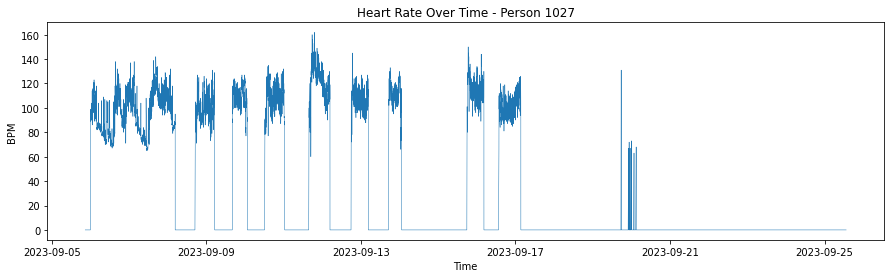

In [59]:
import matplotlib.pyplot as plt

hr_df = df[df['reading_type'] == 'HR'].copy()
hr_df['value'] = hr_df['value'].astype(float)

plt.figure(figsize=(15, 4))
plt.plot(hr_df['timestamp'], hr_df['value'], linewidth=0.5)
plt.title('Heart Rate Over Time - Person 1027')
plt.xlabel('Time')
plt.ylabel('BPM')
plt.show()